# Bitcoin Market Sentiment Analysis
## Exploring the Relationship Between Market Sentiment and Trader Performance

In [2]:
import sys
print(sys.executable)

c:\Users\DELL\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
!pip install seaborn


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import seaborn as sns

In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [108]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [18]:
os.listdir()

['Bitcoin_Sentiment_analysis.ipynb',
 'fear_greed_index.csv',
 'historical_data.csv']

In [ ]:
sentiment.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [21]:
trades.info()

trades.describe()
trades.shape
trades.info()
trades.describe(include='all')

trades.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [23]:
sentiment.head()
sentiment.info()

sentiment.describe()
sentiment.shape
sentiment.info()
sentiment.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


,timestamp,value,classification,date
count,2.644000e+03,2644.000000,2644,2644
unique,NaN,NaN,5,2644
top,NaN,NaN,Fear,2018-02-01
freq,NaN,NaN,781,1
mean,1.631899e+09,46.981089,NaN,NaN
std,6.597967e+07,21.827680,NaN,NaN
min,1.517463e+09,5.000000,NaN,NaN
25%,1.574811e+09,28.000000,NaN,NaN
50%,1.631900e+09,46.000000,NaN,NaN
75%,1.688989e+09,66.000000,NaN,NaN


In [24]:
trades.duplicated().sum()

np.int64(0)

In [25]:
sentiment.duplicated().sum()

np.int64(0)

In [26]:
trades.drop_duplicates(inplace=True)
sentiment.drop_duplicates(inplace=True)

In [27]:
print(trades.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [29]:
trades[['Timestamp IST', 'Timestamp']].head()

,Timestamp IST,Timestamp
0,02-12-2024 22:50,1.730000e+12
1,02-12-2024 22:50,1.730000e+12
2,02-12-2024 22:50,1.730000e+12
3,02-12-2024 22:50,1.730000e+12
4,02-12-2024 22:50,1.730000e+12


In [30]:
sentiment[['date', 'timestamp']].head()

,date,timestamp
0,2018-02-01,1517463000
1,2018-02-02,1517549400
2,2018-02-03,1517635800
3,2018-02-04,1517722200
4,2018-02-05,1517808600


In [32]:
# Convert trade timestamp
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
)

trades['Date'] = trades['Timestamp IST'].dt.date

In [33]:
trades['Timestamp IST'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)

trades['Date'] = trades['Timestamp IST'].dt.date

In [34]:
sentiment[['date']].head(10)

,date
0,2018-02-01
1,2018-02-02
2,2018-02-03
3,2018-02-04
4,2018-02-05
5,2018-02-06
6,2018-02-07
7,2018-02-08
8,2018-02-09
9,2018-02-10


In [38]:
sentiment['date'].head(20)
sentiment['date'].sample(20, random_state=42)
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [39]:
sentiment['date'] = pd.to_datetime(
    sentiment['date'],
    format='mixed',
    dayfirst=True,
    errors='coerce'
)

sentiment['Date'] = sentiment['date'].dt.date

In [41]:
sentiment['date'].isna().sum()
sentiment['date'].head(20)


0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
5    2018-02-06
6    2018-02-07
7    2018-02-08
8    2018-02-09
9    2018-02-10
10   2018-02-11
11   2018-02-12
12   2018-02-13
13   2018-02-14
14   2018-02-15
15   2018-02-16
16   2018-02-17
17   2018-02-18
18   2018-02-19
19   2018-02-20
Name: date, dtype: datetime64[ns]

In [42]:
sentiment['Date'] = sentiment['date'].dt.date

In [44]:
print(trades['Date'].min(), trades['Date'].max())
print(sentiment['Date'].min(), sentiment['Date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


In [45]:
# Check the data types first
print(trades['Date'].dtype)
print(sentiment['Date'].dtype)

object
object


In [46]:
df = pd.merge(
    trades,
    sentiment[['Date', 'classification']],
    on='Date',
    how='left'
)

In [47]:
df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [49]:
df['classification'].isnull().sum()
df[['Date', 'classification']].head(10)


,Date,classification
0,2024-12-02,Extreme Greed
1,2024-12-02,Extreme Greed
2,2024-12-02,Extreme Greed
3,2024-12-02,Extreme Greed
4,2024-12-02,Extreme Greed
5,2024-12-02,Extreme Greed
6,2024-12-02,Extreme Greed
7,2024-12-02,Extreme Greed
8,2024-12-02,Extreme Greed
9,2024-12-02,Extreme Greed


In [53]:
df["Trade Result"] = np.where(
    df["Closed PnL"] > 0,
    "Profit",
    "Loss"
)

In [54]:
df["Hour"] = df["Timestamp IST"].dt.hour


In [55]:
df["Day"] = df["Timestamp IST"].dt.day_name()
df["Month"] = df["Timestamp IST"].dt.month_name()

In [56]:
df["Trade Value"] = df["Size USD"]


# Exploratory Data Analysis (EDA)

In [57]:
print("Total Trades:", len(df))

Total Trades: 211224


In [61]:
print("Unique Traders:", df["Account"].nunique())
print("Unique Coins:", df["Coin"].nunique())

Unique Traders: 32
Unique Coins: 246


In [62]:
df["Coin"].value_counts()


Coin
HYPE    68005
@107    29992
BTC     26064
ETH     11158
SOL     10691
        ...  
@18         1
@30         1
@25         1
@86         1
@68         1
Name: count, Length: 246, dtype: int64

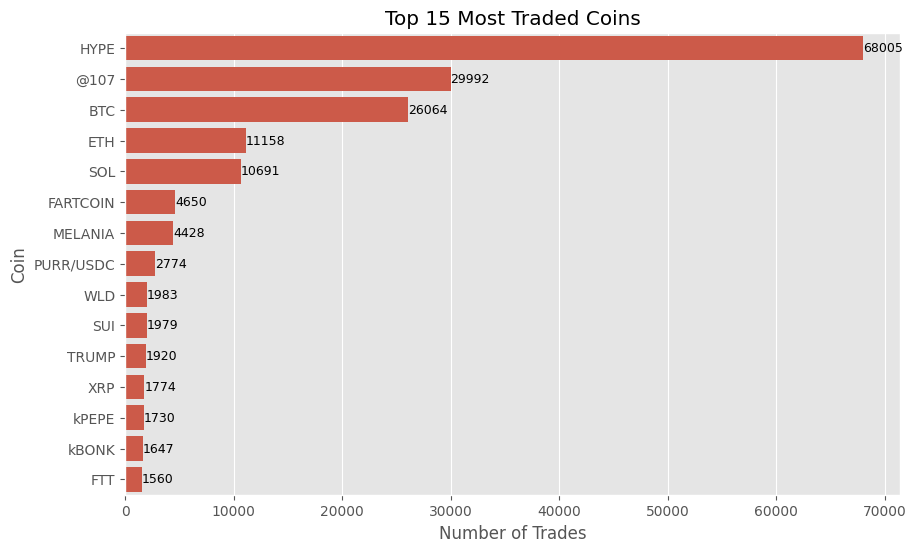

In [105]:
# plt.figure(figsize=(10,5))

# sns.countplot(
#     data=df,
#     y="Coin",
#     order=df["Coin"].value_counts().index
# )

# plt.title("Most Traded Coins")
# plt.xlabel("Number of Trades")
# plt.ylabel("Coin")

# plt.show()




# Top 15 most traded coins
top15 = df["Coin"].value_counts().head(15)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=top15.values,
    y=top15.index
)

plt.title("Top 15 Most Traded Coins")
plt.xlabel("Number of Trades")
plt.ylabel("Coin")

# Add labels
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.show()

This chart shows the trading frequency of each cryptocurrency. The most traded coins indicate where traders were most active.

Observation
The chart displays the Top 15 most traded cryptocurrencies based on the total number of trades executed.

Interpretation
The analysis shows that trading activity is concentrated in a small number of cryptocurrencies. The most traded coins attract significantly higher trading volumes than the remaining assets, indicating that traders prefer highly liquid and widely recognized cryptocurrencies. This concentration suggests greater market participation and better liquidity in these assets.

Business Recommendation
Traders and exchanges can prioritize highly traded cryptocurrencies, as they generally provide better liquidity, faster trade execution, and lower transaction costs. Focusing on actively traded assets can also improve trading efficiency and reduce execution risk.

Key Findings
Trading activity is concentrated among a few cryptocurrencies.
The top-ranked coins dominate the overall number of trades.
Less frequently traded coins receive comparatively lower market participation.
High trading volume often indicates greater market liquidity and trader interest.

In [64]:
df["Side"].value_counts()

Side
SELL    108528
BUY     102696
Name: count, dtype: int64

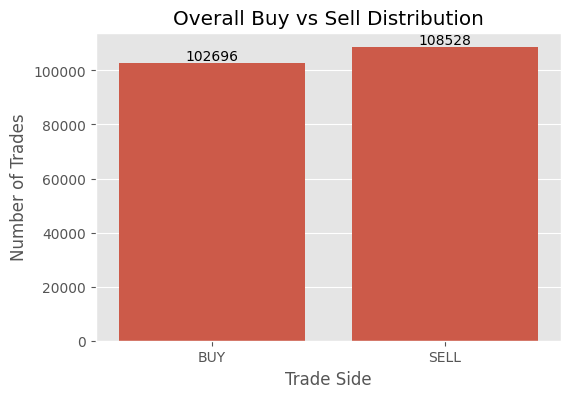

In [ ]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Side"
)

plt.title("Overall Buy vs Sell Distribution")
plt.xlabel("Trade Side")
plt.ylabel("Number of Trades")

# Add count labels
for container in ax.containers:
    ax.bar_label(container)

plt.show()

Insight
The chart shows that the dataset contains 102,696 BUY trades and 108,528 SELL trades. SELL trades slightly outnumber BUY trades, indicating a small preference for selling over buying. Overall, the nearly balanced distribution suggests active participation from both buyers and sellers, reflecting a liquid market.

Key Finding
BUY Trades: 102,696
SELL Trades: 108,528
SELL trades are slightly more frequent than BUY trades.

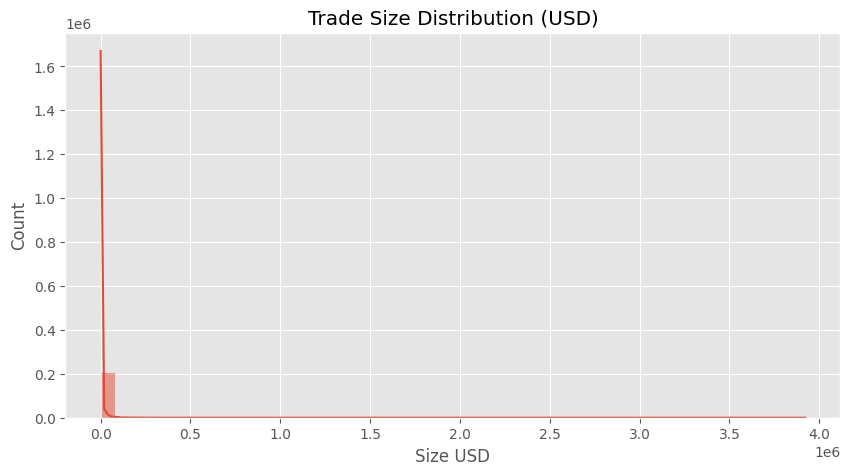

In [66]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["Size USD"],
    bins=50,
    kde=True
)

plt.title("Trade Size Distribution (USD)")

plt.show()

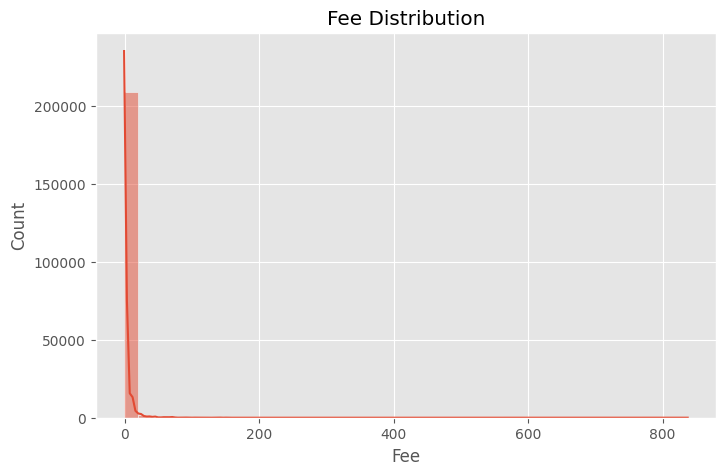

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Fee"],
    bins=40,
    kde=True
)

plt.title("Fee Distribution")

plt.show()

The histogram shows that most trades incur very low fees, while only a small number of trades have high fees. The distribution is highly right-skewed, indicating that high-fee trades are rare.

Key Findings
Most trading fees are concentrated near 0 USD.
Only a few trades have exceptionally high fees.
The fee distribution is right-skewed, with a small number of outliers.
Business Recommendation

Most traders incur low transaction costs, while large or high-value trades contribute to higher fees. Monitoring these high-fee trades can help optimize trading costs and improve overall profitability.

In [68]:
df["Direction"].value_counts()

Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64

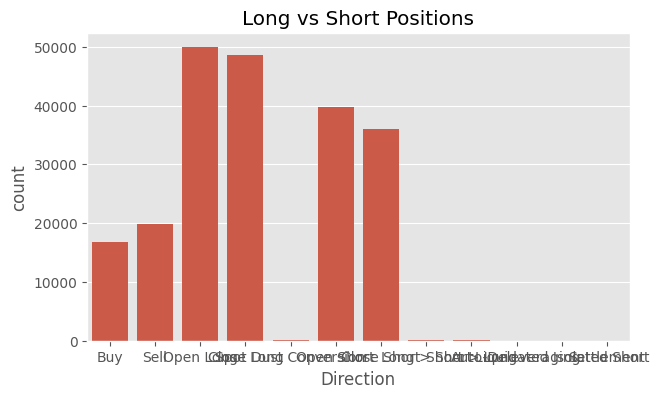

In [69]:
plt.figure(figsize=(7,4))

sns.countplot(
    data=df,
    x="Direction"
)

plt.title("Long vs Short Positions")

plt.show()

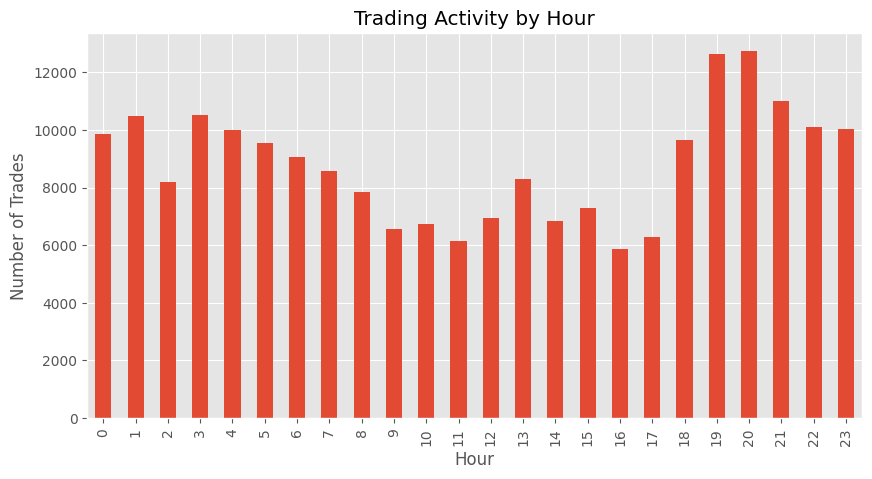

In [70]:
hourly = df.groupby("Hour").size()

plt.figure(figsize=(10,5))

hourly.plot(kind="bar")

plt.title("Trading Activity by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Trades")

plt.show()

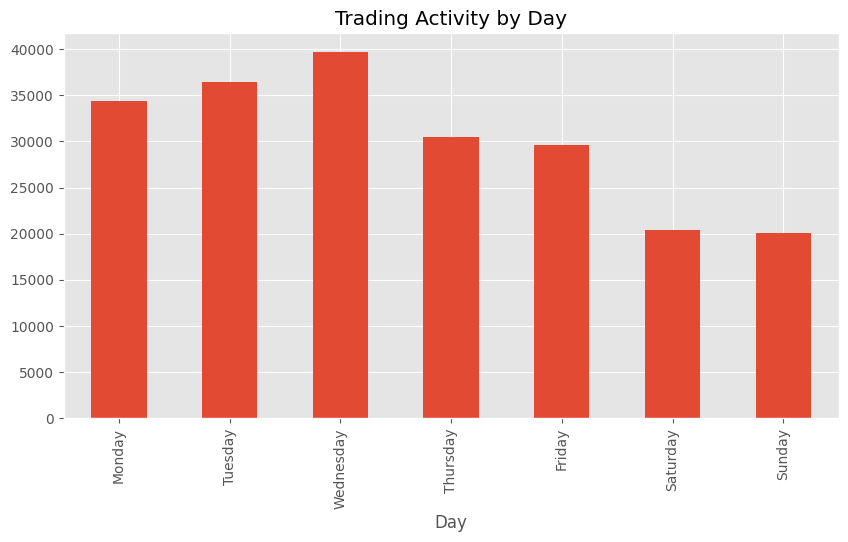

In [71]:
daily = df.groupby("Day").size()

daily = daily.reindex([
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
])

plt.figure(figsize=(10,5))

daily.plot(kind="bar")

plt.title("Trading Activity by Day")

plt.show()

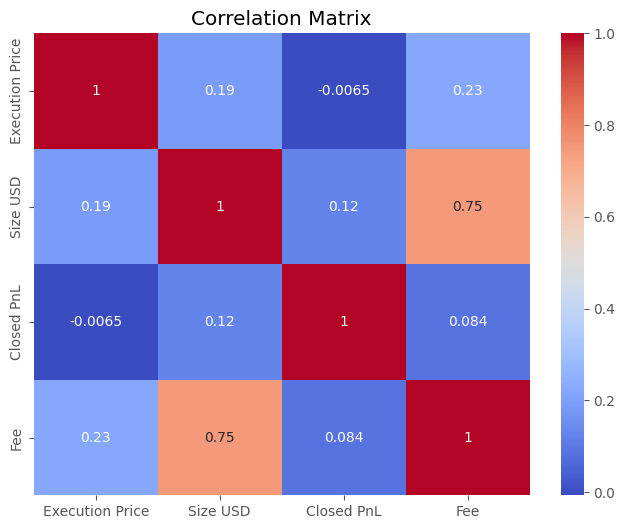

In [72]:
plt.figure(figsize=(8,6))

corr = df[
    [
        "Execution Price",
        "Size USD",
        "Closed PnL",
        "Fee"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

# Market Sentiment Analysis

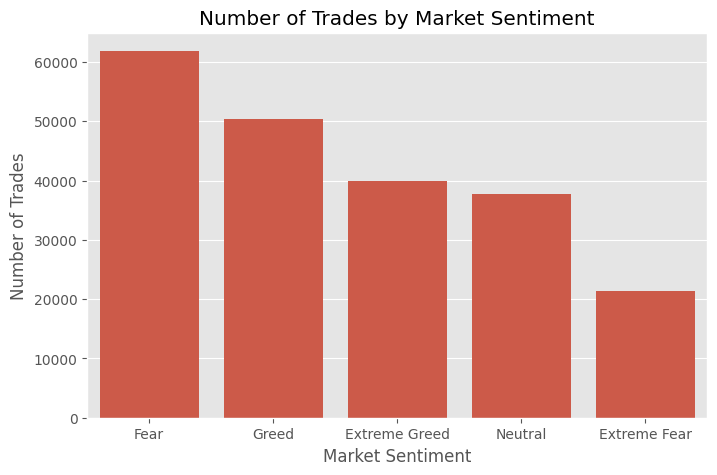

In [73]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="classification",
    order=df["classification"].value_counts().index
)

plt.title("Number of Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

plt.show()

This chart shows how trading activity is distributed across different market sentiment categories. It helps identify whether traders are more active during Fear or Greed periods.

The chart shows that the highest number of trades occurred during Fear (approximately 62,000 trades), followed by Greed (approximately 50,000 trades). Extreme Fear recorded the lowest trading activity (approximately 21,000 trades). This suggests that traders were most active during Fear markets, indicating increased participation during periods of uncertainty and volatility.

Key Findings
Fear had the highest number of trades.
Greed recorded the second-highest trading activity.
Extreme Fear had the lowest number of trades.
Trading activity varies with market sentiment, with higher participation during Fear and Greed periods.
Business Recommendation

Trading firms can use market sentiment to anticipate changes in trading volume. Higher activity during Fear and Greed periods may create more trading opportunities but also increase market volatility, making effective risk management essential.

In [74]:
avg_pnl = df.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

print(avg_pnl)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


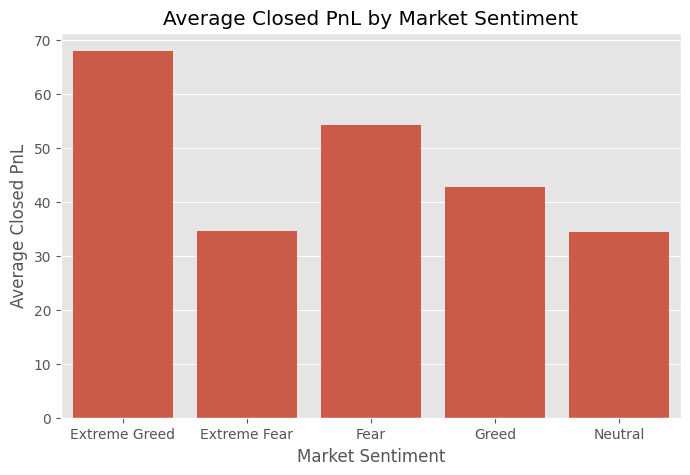

In [75]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="classification",
    y="Closed PnL",
    estimator="mean",
    errorbar=None
)

plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")

plt.show()

The chart shows that Extreme Greed has the highest average Closed PnL (≈68), followed by Fear (≈54). In contrast, Extreme Fear and Neutral have the lowest average Closed PnL (≈35). This indicates that trader profitability tends to be higher during Extreme Greed and Fear market conditions.

Key Findings
Highest Average Closed PnL: Extreme Greed (≈68)
Second Highest: Fear (≈54)
Lowest Average Closed PnL: Extreme Fear and Neutral (≈35)
Market sentiment appears to influence trader profitability, with better average returns during Extreme Greed.
Business Recommendation

Traders can use market sentiment as an additional indicator when making trading decisions. While Extreme Greed is associated with the highest average profits in this dataset, trading decisions should always be supported by proper risk management and technical analysis rather than sentiment alone.

In [76]:
df.groupby("classification")["Closed PnL"].median()

classification
Extreme Fear     0.0
Extreme Greed    0.0
Fear             0.0
Greed            0.0
Neutral          0.0
Name: Closed PnL, dtype: float64

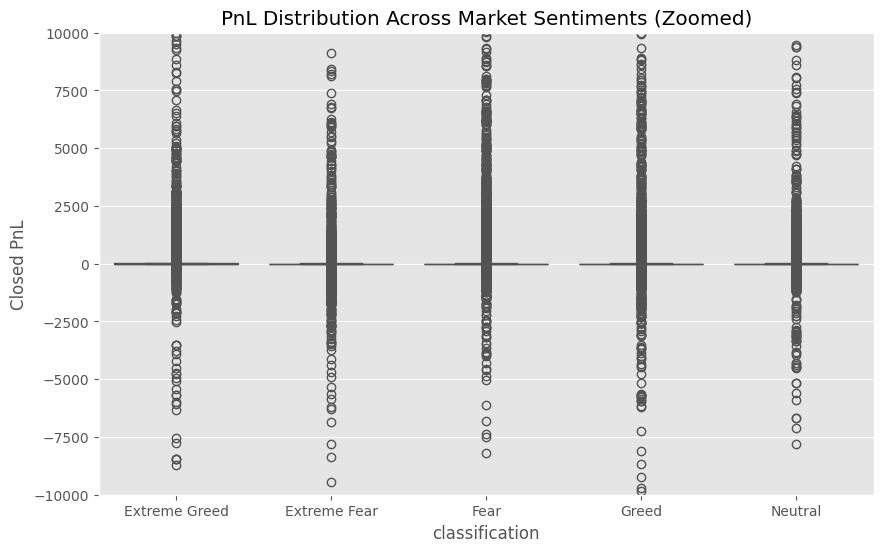

In [99]:
# plt.figure(figsize=(10,6))

# sns.boxplot(
#     data=df,
#     x="classification",
#     y="Closed PnL"
# )

# plt.title("PnL Distribution Across Market Sentiments")

# plt.show()


plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="classification",
    y="Closed PnL"
)

plt.ylim(-10000, 10000)

plt.title("PnL Distribution Across Market Sentiments (Zoomed)")
plt.show()


# plt.figure(figsize=(10,6))

# sns.boxplot(
#     data=df,
#     x="classification",
#     y="Closed PnL",
#     showfliers=False
# )

# plt.title("PnL Distribution Across Market Sentiments")
# plt.show()

Insight

The box plot illustrates the distribution of Closed PnL across different market sentiment categories such as Extreme Fear, Fear, Neutral, Greed and Extreme Greed. Most trades are concentrated around zero, indicating that the majority of trades result in relatively small profits or losses. However, all sentiment categories contain several outliers, representing trades with exceptionally high profits or significant losses.

The Fear and Greed categories show a wider spread of PnL values, suggesting greater variability in trader performance during these market conditions. This indicates that emotionally driven markets are associated with higher trading risk as well as the potential for larger rewards. Overall, the chart highlights that while market sentiment influences the distribution of trading outcomes, extreme profit and loss events can occur under any market condition.

Conclusion
Most trades generate small profits or losses.
All market sentiment categories contain extreme profit and loss outliers.
Fear and Greed periods exhibit greater variability in trading outcomes, indicating higher market volatility.
Traders should apply effective risk management strategies, especially during highly volatile market conditions.

In [78]:
df["Trade Result"] = np.where(
    df["Closed PnL"] > 0,
    "Profit",
    "Loss"
)

In [79]:
win_rate = (
    pd.crosstab(df["classification"], df["Trade Result"], normalize="index") * 100
)

print(win_rate)

Trade Result         Loss     Profit
classification                      
Extreme Fear    62.939252  37.060748
Extreme Greed   53.505701  46.494299
Fear            57.923250  42.076750
Greed           61.517206  38.482794
Neutral         60.300907  39.699093


<Figure size 900x500 with 0 Axes>

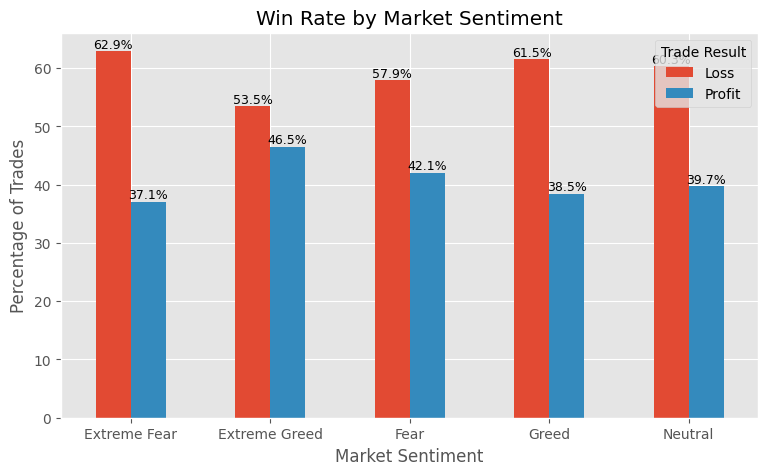

In [101]:
# win_rate.plot(
#     kind="bar",
#     figsize=(9,5)
# )

# plt.title("Win Rate by Market Sentiment")
# plt.ylabel("Percentage")

# plt.show()




plt.figure(figsize=(9,5))

ax = win_rate.plot(
    kind="bar",
    figsize=(9,5)
)

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Percentage of Trades")
plt.xticks(rotation=0)
plt.legend(title="Trade Result")

# Add percentage labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', fontsize=9)

plt.show()

Insight: Win Rate by Market Sentiment

The chart compares the percentage of profitable and loss-making trades across different Bitcoin market sentiment categories.
The analysis reveals that loss-making trades outnumber profitable trades under every market sentiment, indicating that traders generally experienced more losing trades than winning trades. This highlights the challenging and volatile nature of cryptocurrency trading.
Among all sentiment categories, Extreme Greed recorded the highest profit rate (46.5%) and the lowest loss rate (53.5%), suggesting that traders achieved relatively better performance during periods of strong market optimism.
On the other hand, Extreme Fear showed the lowest profit rate (37.1%) and the highest loss rate (62.9%), indicating that traders struggled to generate profitable trades when market sentiment was highly pessimistic.
The Fear, Greed, and Neutral categories exhibited similar trading patterns, with profit rates ranging from 38.5% to 42.1%, while losses remained the majority. This suggests that although market sentiment influences trader performance, it is not the only factor affecting trading outcomes.
Overall, the findings indicate that trader performance tends to improve as market sentiment becomes more positive, but maintaining disciplined risk management remains essential regardless of market conditions.

Key Findings:
Loss making trades exceed profitable trades across all market sentiment categories.
Extreme Greed achieved the highest profit rate (46.5%) and the lowest loss rate (53.5%).
Extreme Fear recorded the lowest profit rate (37.1%) and the highest loss rate (62.9%).
Fear, Greed, and Neutral markets show similar win-loss distributions.
Positive market sentiment appears to improve trader performance, but it does not eliminate trading risk.
Business Recommendation

The results suggest that market sentiment has a measurable impact on trading performance. Traders appear to perform better during Extreme Greed periods, while Extreme Fear is associated with a lower probability of profitable trades. Trading strategies should therefore incorporate market sentiment as one of the decision-making factors. However, sentiment alone should not drive trading decisions like effective risk management, disciplined position sizing, and sound technical or fundamental analysis remain essential for achieving consistent profitability.

In [81]:
trade_size = df.groupby("classification")["Size USD"].mean()

print(trade_size)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


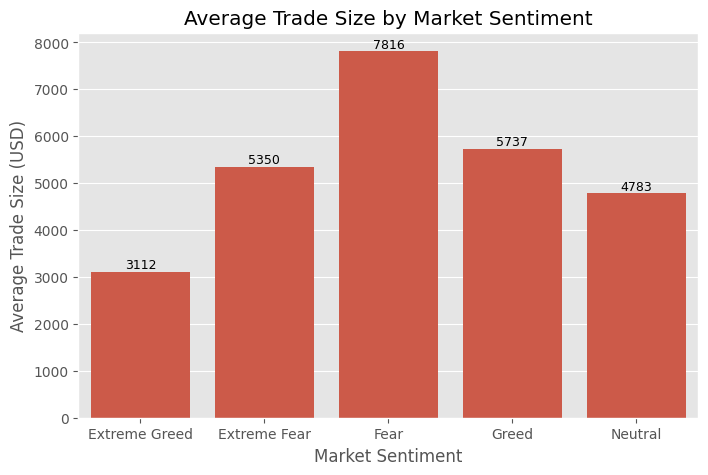

In [103]:
# plt.figure(figsize=(8,5))

# sns.barplot(
#     data=df,
#     x="classification",
#     y="Size USD",
#     estimator="mean",
#     errorbar=None
# )

# plt.title("Average Trade Size by Market Sentiment")

# plt.show()





plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=df,
    x="classification",
    y="Size USD",
    estimator="mean",
    errorbar=None
)

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9)

plt.show()

Insight

The chart shows that Fear has the highest average trade size (7,816 USD), followed by Greed (5,737 USD) and Extreme Fear (5,350 USD). In contrast, Extreme Greed has the lowest average trade size (3,112 USD).

This suggests that traders tend to take larger positions during Fear periods, possibly to capitalize on market volatility or lower asset prices. On the other hand, traders appear to adopt smaller position sizes during Extreme Greed, indicating a more cautious approach despite positive market sentiment.

Key Finding
Highest Average Trade Size: Fear (7,816 USD)
Lowest Average Trade Size: Extreme Greed (3,112 USD)
Market sentiment appears to influence traders' position sizing and risk-taking behavior.

In [83]:
volume = df.groupby("classification")["Size USD"].sum()

print(volume)

classification
Extreme Fear     1.144843e+08
Extreme Greed    1.244652e+08
Fear             4.833248e+08
Greed            2.885825e+08
Neutral          1.802421e+08
Name: Size USD, dtype: float64


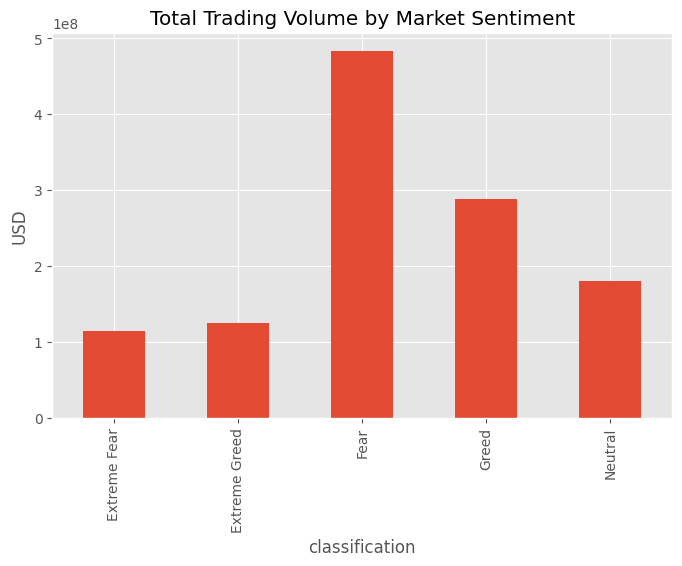

In [84]:
volume.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Trading Volume by Market Sentiment")

plt.ylabel("USD")

plt.show()

In [85]:
buy_sell = pd.crosstab(
    df["classification"],
    df["Side"]
)

print(buy_sell)

Side              BUY   SELL
classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


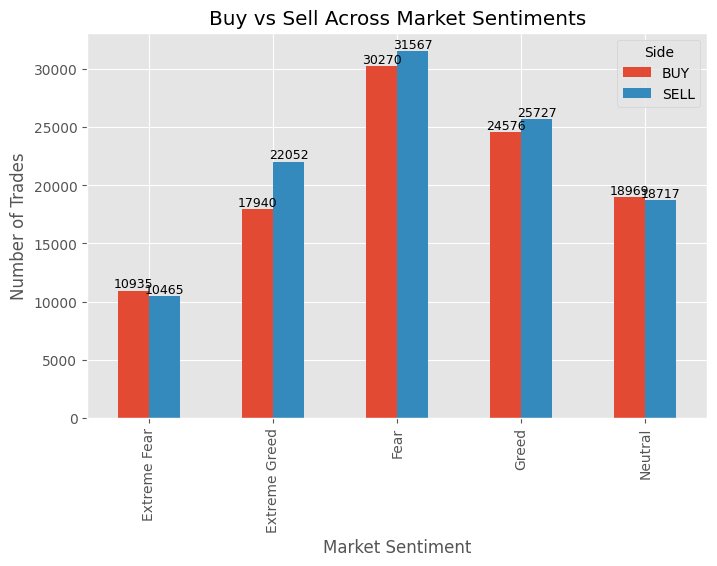

In [104]:
# buy_sell.plot(
#     kind="bar",
#     figsize=(8,5)
# )

# plt.title("Buy vs Sell Across Market Sentiments")

# plt.ylabel("Number of Trades")

# plt.show()





ax = buy_sell.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Buy vs Sell Across Market Sentiments")
plt.xlabel("Market Sentiment")
plt.ylabel("Number of Trades")

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fontsize=9)

plt.show()

Observation
The chart compares the number of BUY and SELL trades across different Bitcoin market sentiment categories.
Fear recorded the highest trading activity, with 30,270 BUY trades and 31,567 SELL trades.
Extreme Fear had the lowest trading activity, with 10,935 BUY trades and 10,465 SELL trades.
In Fear, Greed, and Extreme Greed, SELL trades slightly exceeded BUY trades.
Neutral sentiment showed an almost equal number of BUY (18,969) and SELL (18,717) trades.



Interpretation
The results indicate that market sentiment influences trading behavior. Traders were most active during Fear periods, suggesting that increased market uncertainty leads to higher trading activity. The slightly higher number of SELL trades in most sentiment categories may indicate that traders were more likely to close positions or take profits. In contrast, the nearly equal BUY and SELL trades during Neutral sentiment suggest a balanced market with no strong directional bias.

Business Recommendation
Trading firms can use market sentiment to anticipate changes in trading activity. During Fear periods, increased market participation may create more trading opportunities but also higher volatility, making effective risk management essential. The balanced trading observed during Neutral sentiment indicates relatively stable market conditions.

Key Findings
Fear had the highest number of BUY (30,270) and SELL (31,567) trades.
Extreme Fear had the lowest overall trading activity.
SELL trades slightly outnumbered BUY trades in most market sentiment categories.
Neutral sentiment showed the most balanced BUY and SELL activity.
Market sentiment has a noticeable impact on traders' buying and selling behavior.

In [87]:
direction = pd.crosstab(
    df["classification"],
    df["Direction"]
)

print(direction)

Direction       Auto-Deleveraging   Buy  Close Long  Close Short  \
classification                                                     
Extreme Fear                    0   807        6241         3117   
Extreme Greed                   0  5132        7186         6497   
Fear                            0  3207       17260         9221   
Greed                           8  4685        7998        11322   
Neutral                         0  2885        9993         5850   

Direction       Liquidated Isolated Short  Long > Short  Open Long  \
classification                                                       
Extreme Fear                            0             5       7005   
Extreme Greed                           0             7       6300   
Fear                                    0            14      17824   
Greed                                   1            16       8544   
Neutral                                 0            15      10222   

Direction       Open Short  Sell

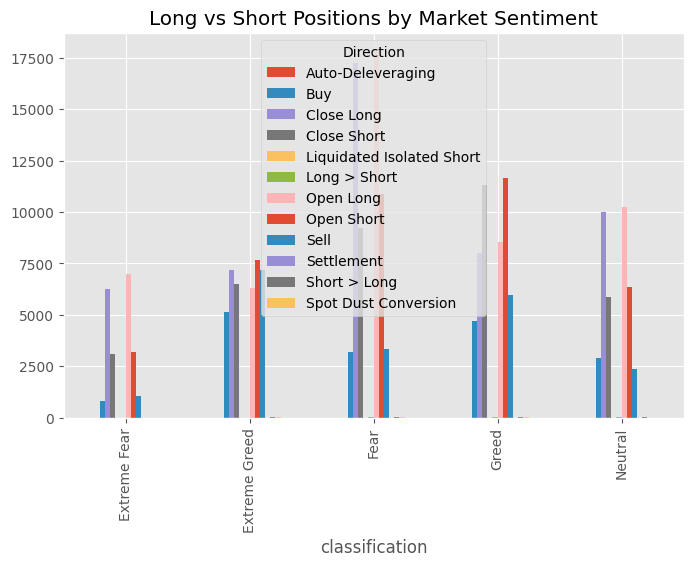

In [88]:
direction.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Long vs Short Positions by Market Sentiment")

plt.show()

In [89]:
fees = df.groupby("classification")["Fee"].mean()

print(fees)

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64


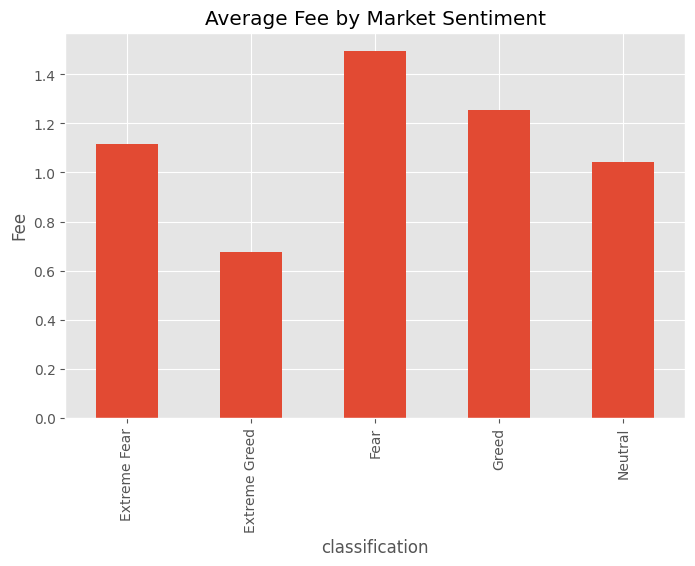

In [90]:
fees.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Fee by Market Sentiment")

plt.ylabel("Fee")

plt.show()

In [91]:
coin_pnl = df.pivot_table(
    values="Closed PnL",
    index="Coin",
    columns="classification",
    aggfunc="mean"
)

coin_pnl

classification,Extreme Fear,Extreme Greed,Fear,Greed,Neutral
Coin,,,,,
@1,NaN,18.358058,0.000000,0.179780,NaN
@10,-0.031742,NaN,0.000000,0.000000,NaN
@100,NaN,6.906785,NaN,NaN,NaN
@103,NaN,6.812669,NaN,2.247346,NaN
@107,-89.588788,191.158211,-2.291257,86.251763,52.150107
...,...,...,...,...,...
kBONK,NaN,50.274649,24.736833,-2.724259,0.896872
kFLOKI,NaN,50.216813,NaN,15.543654,4.083950
kNEIRO,NaN,NaN,NaN,2.039936,-2.840308


In [94]:
top20 = df["Coin"].value_counts().head(20).index

coin_pnl = (
    df[df["Coin"].isin(top20)]
    .pivot_table(
        values="Closed PnL",
        index="Coin",
        columns="classification",
        aggfunc="mean"
    )
)

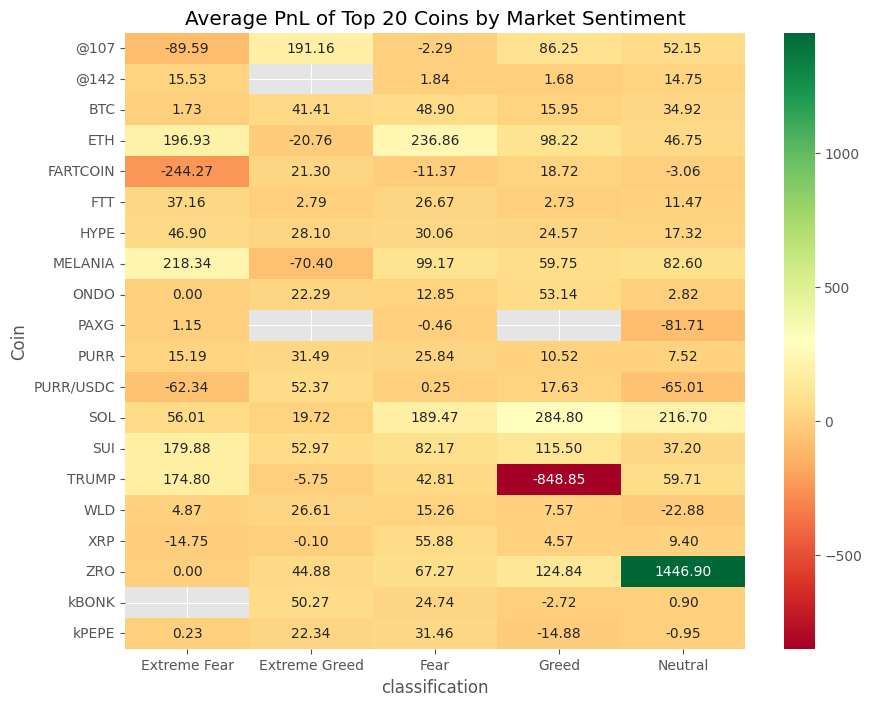

In [95]:
plt.figure(figsize=(10,8))

sns.heatmap(
    coin_pnl,
    annot=True,
    cmap="RdYlGn",
    fmt=".2f"
)

plt.title("Average PnL of Top 20 Coins by Market Sentiment")

plt.show()

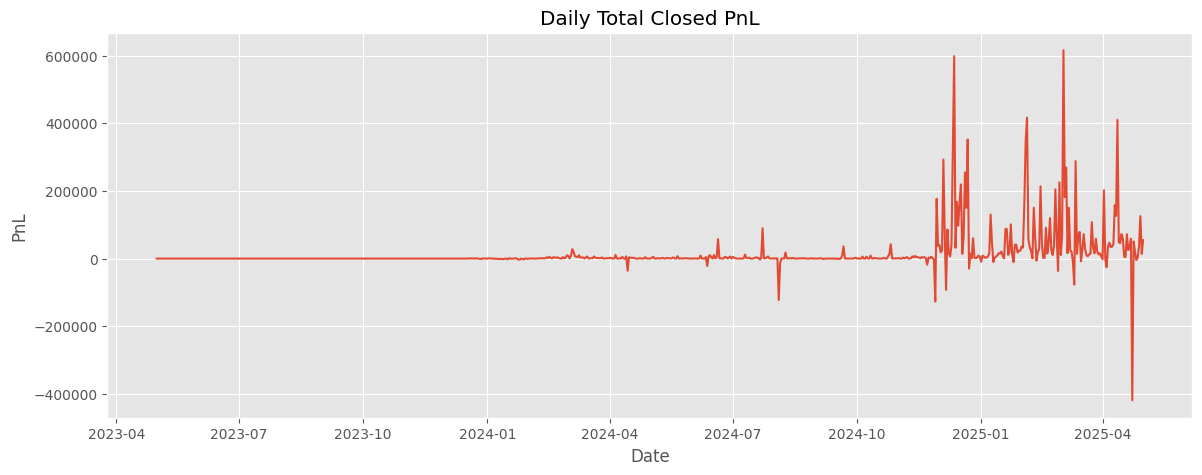

In [93]:
daily_profit = df.groupby("Date")["Closed PnL"].sum()

plt.figure(figsize=(14,5))

daily_profit.plot()

plt.title("Daily Total Closed PnL")

plt.ylabel("PnL")

plt.show()